# Synthetic Housing Market EDA (20-Year Horizon)

This notebook performs a full exploratory analysis of `synthetic_house_prices_20_years.csv` with focus on:

1. Data integrity and cleaning
2. Descriptive statistics
3. Time-series trends and seasonality
4. Feature impact and correlation
5. Geographic variation and neighborhood growth


In [36]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)


## Load Data

In [37]:
DATA_PATH = "data/synthetic_house_prices_20_years.csv"
df_raw = pd.read_csv(DATA_PATH)
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head()

Shape: 3520 rows x 14 columns


,Neighborhood,Year,Season,Property Type,Bedrooms,Bathrooms,Year Built,Renovation Year,Garage Type,Square Footage (House),Square Footage (Land),Basement,Legal Units,Market Price
0,Kitsilano,2004,Spring,Triplex,1,3,1954,2000.0,Double,1308,6742,Not Finished,2,1734587.40
1,Kitsilano,2004,Summer,Condo,3,1,2022,NaN,Single,3947,2592,Finished,0,951731.62
2,Kitsilano,2004,Fall,House,4,1,2006,NaN,NaN,919,9519,Not Finished,2,1782016.80
3,Kitsilano,2004,Winter,Condo,2,2,1960,NaN,Triple,2352,1555,Not Finished,2,335768.06
4,Kitsilano,2005,Spring,Duplex,5,2,1960,1992.0,NaN,2474,7031,Not Finished,0,1571528.42


## 1) Data Integrity & Cleaning

In [38]:
# Missing values
missing_values = df_raw.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing_values["missing_pct"] = (missing_values["missing_count"] / len(df_raw) * 100).round(2)
missing_values

,missing_count,missing_pct
Renovation Year,2017,57.30
Garage Type,946,26.88
Neighborhood,0,0.00
Year,0,0.00
Season,0,0.00
Property Type,0,0.00
Bedrooms,0,0.00
Bathrooms,0,0.00
Year Built,0,0.00
Square Footage (House),0,0.00


In [39]:
# Cleaning strategy for missing fields
df = df_raw.copy()

# Categorical treatment for missing renovation years
# (keep original numeric column for reference, add explicit status)
df["Renovation Status"] = np.where(df["Renovation Year"].isna(), "No Renovation", "Renovated")

# Missing garage type is treated as no garage
df["Garage Type"] = df["Garage Type"].fillna("No Garage")

# Ensure integer type for year fields
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df["Year Built"] = pd.to_numeric(df["Year Built"], errors="coerce").astype("Int64")

# Derived feature for age; negative age indicates invalid chronology
raw_age = df["Year"] - df["Year Built"]
df["Age of Property"] = raw_age.where(raw_age >= 0, np.nan)

# Renovation lag relative to sale year (where renovation exists)
df["Renovation Lag"] = (df["Year"] - df["Renovation Year"]).where(df["Renovation Year"].notna(), np.nan)

print("Dtypes after cleaning:")
print(df.dtypes)

print("\nNegative age rows flagged as NaN in 'Age of Property':", raw_age.lt(0).sum())

Dtypes after cleaning:
Neighborhood               object
Year                        Int64
Season                     object
Property Type              object
Bedrooms                    int64
Bathrooms                   int64
Year Built                  Int64
Renovation Year           float64
Garage Type                object
Square Footage (House)      int64
Square Footage (Land)       int64
Basement                   object
Legal Units                 int64
Market Price              float64
Renovation Status          object
Age of Property             Int64
Renovation Lag            Float64
dtype: object

Negative age rows flagged as NaN in 'Age of Property': 446


In [40]:
# Validate numeric ranges / impossible values
integrity_checks = {
    "Bedrooms < 0": int((df["Bedrooms"] < 0).sum()),
    "Bathrooms < 0": int((df["Bathrooms"] < 0).sum()),
    "House SqFt <= 0": int((df["Square Footage (House)"] <= 0).sum()),
    "Land SqFt <= 0": int((df["Square Footage (Land)"] <= 0).sum()),
    "Year Built > Year (chronology issue)": int((df["Year Built"] > df["Year"]).sum()),
}

pd.Series(integrity_checks, name="count").to_frame()

,count
Bedrooms < 0,0
Bathrooms < 0,0
House SqFt <= 0,0
Land SqFt <= 0,0
Year Built > Year (chronology issue),446


In [41]:
# Outlier detection (IQR and Z-score)
outlier_rows = []
for col in ["Market Price", "Square Footage (House)", "Square Footage (Land)"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    z = ((df[col] - df[col].mean()) / df[col].std(ddof=0)).abs()
    z_outliers = (z > 3).sum()

    outlier_rows.append({
        "variable": col,
        "IQR_outliers": int(iqr_outliers),
        "IQR_outlier_pct": round(iqr_outliers / len(df) * 100, 2),
        "Z>3_outliers": int(z_outliers),
        "Z>3_outlier_pct": round(z_outliers / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,variable,IQR_outliers,IQR_outlier_pct,Z>3_outliers,Z>3_outlier_pct
0,Market Price,85,2.41,38,1.08
1,Square Footage (House),0,0.00,0,0.00
2,Square Footage (Land),0,0.00,0,0.00


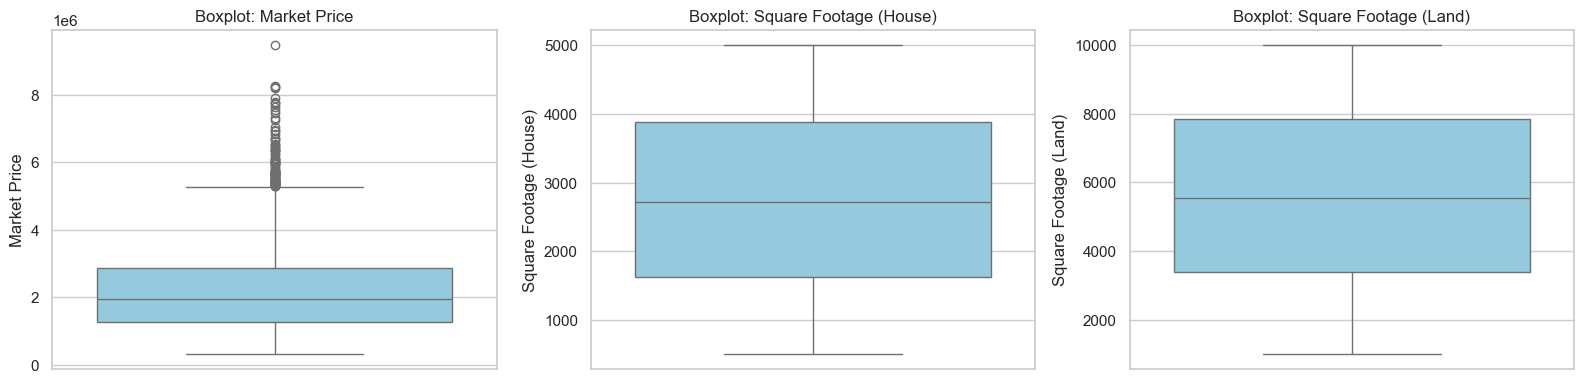

In [42]:
# Boxplots for outlier visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_cols = ["Market Price", "Square Footage (House)", "Square Footage (Land)"]

for ax, col in zip(axes, plot_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

## 2) Descriptive Statistics

In [43]:
summary_table = (
    df[["Market Price", "Square Footage (House)", "Square Footage (Land)"]]
    .agg(["mean", "median", "std"]).T
    .rename_axis("variable")
)
summary_table

,mean,median,std
variable,,,
Market Price,2.205096e+06,1945504.854,1.252980e+06
Square Footage (House),2.741978e+03,2722.000,1.293929e+03
Square Footage (Land),5.574964e+03,5559.500,2.609558e+03


In [44]:
# Frequency distributions for key categorical variables
categorical_columns = ["Property Type", "Neighborhood", "Basement", "Garage Type", "Season", "Renovation Status"]
frequency_tables = {col: df[col].value_counts(dropna=False) for col in categorical_columns}

for col, counts in frequency_tables.items():
    print(f"\n=== {col} ===")
    print(counts)



=== Property Type ===
Property Type
Duplex       731
Condo        730
Townhouse    719
House        677
Triplex      663
Name: count, dtype: int64

=== Neighborhood ===
Neighborhood
Downtown                  160
Kitsilano                  80
Riverwood                  80
Ladner                     80
North Delta                80
Tsawwassen                 80
Uptown                     80
Queensborough              80
Glenbrook North            80
Mary Hill                  80
Glenwood                   80
Central Port Coquitlam     80
Coquitlam Centre           80
Upper Lonsdale             80
Lower Lonsdale             80
Lynn Valley                80
Central Lonsdale           80
Ambleside                  80
Dundarave                  80
Horseshoe Bay              80
British Properties         80
Maillardville              80
Burke Mountain             80
Mount Pleasant             80
Westwood Plateau           80
West End                   80
East Vancouver             80
Guildfo

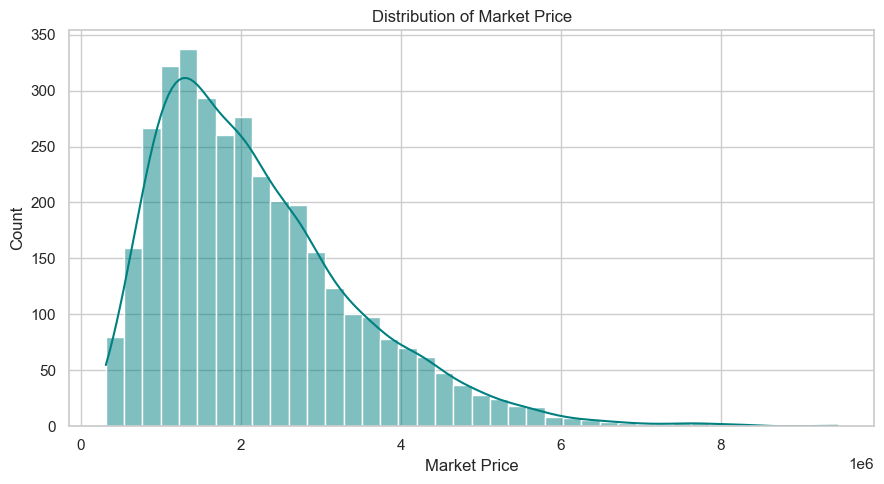

In [45]:
# Price distribution histogram
plt.figure(figsize=(9, 5))
sns.histplot(df["Market Price"], bins=40, kde=True, color="teal")
plt.title("Distribution of Market Price")
plt.xlabel("Market Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 3) Time-Series Analysis

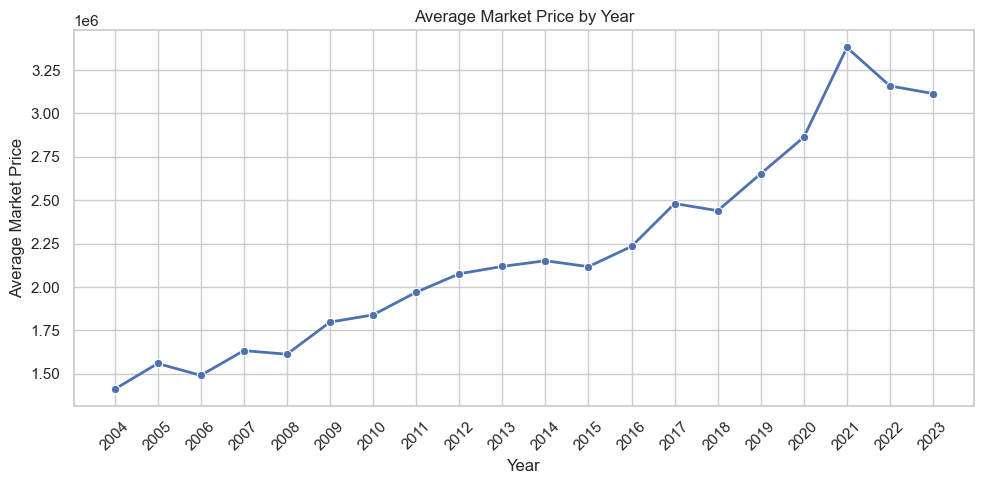

Total growth from 2004 to 2023: 120.73%


In [46]:
# Average price by year (20-year trajectory)
yearly_price = (
    df.groupby("Year", as_index=False)["Market Price"]
    .mean()
    .sort_values("Year")
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_price, x="Year", y="Market Price", marker="o", linewidth=2)
plt.title("Average Market Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Market Price")
plt.xticks(yearly_price["Year"].astype(int).to_list(), rotation=45)
plt.tight_layout()
plt.show()

growth_pct = (yearly_price["Market Price"].iloc[-1] - yearly_price["Market Price"].iloc[0]) / yearly_price["Market Price"].iloc[0] * 100
print(f"Total growth from {int(yearly_price['Year'].iloc[0])} to {int(yearly_price['Year'].iloc[-1])}: {growth_pct:.2f}%")

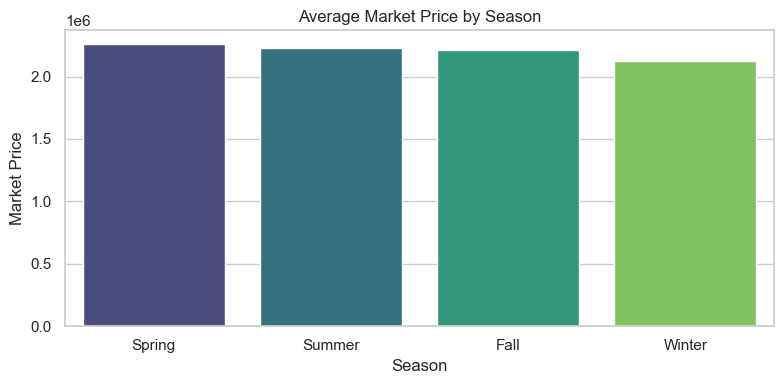

,Season,Market Price
1,Spring,2.256546e+06
2,Summer,2.227813e+06
0,Fall,2.211397e+06
3,Winter,2.124628e+06


In [47]:
# Seasonality in prices
season_order = ["Spring", "Summer", "Fall", "Winter"]
seasonal_price = (
    df.groupby("Season", as_index=False)["Market Price"]
    .mean()
)
seasonal_price["Season"] = pd.Categorical(seasonal_price["Season"], categories=season_order, ordered=True)
seasonal_price = seasonal_price.sort_values("Season")

plt.figure(figsize=(8, 4))
sns.barplot(data=seasonal_price, x="Season", y="Market Price", palette="viridis")
plt.title("Average Market Price by Season")
plt.tight_layout()
plt.show()

seasonal_price

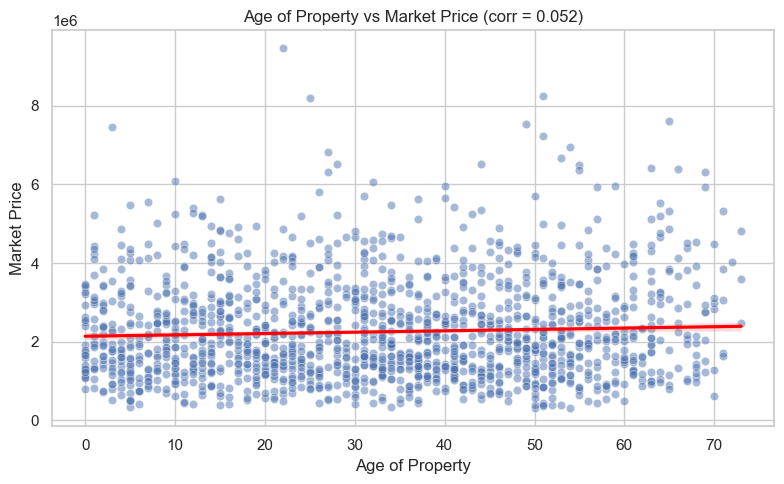

Correlation between Age of Property and Market Price: 0.052


In [48]:
# Age impact on price (excluding invalid negative ages)
valid_age_df = df[df["Age of Property"].notna()].copy()
valid_age_df["Age of Property"] = valid_age_df["Age of Property"].astype(float)
age_price_corr = valid_age_df["Age of Property"].corr(valid_age_df["Market Price"])

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=valid_age_df.sample(min(1500, len(valid_age_df)), random_state=42),
    x="Age of Property",
    y="Market Price",
    alpha=0.5,
)
sns.regplot(data=valid_age_df, x="Age of Property", y="Market Price", scatter=False, color="red")
plt.title(f"Age of Property vs Market Price (corr = {age_price_corr:.3f})")
plt.tight_layout()
plt.show()

print(f"Correlation between Age of Property and Market Price: {age_price_corr:.3f}")

## 4) Feature Correlation & Impact

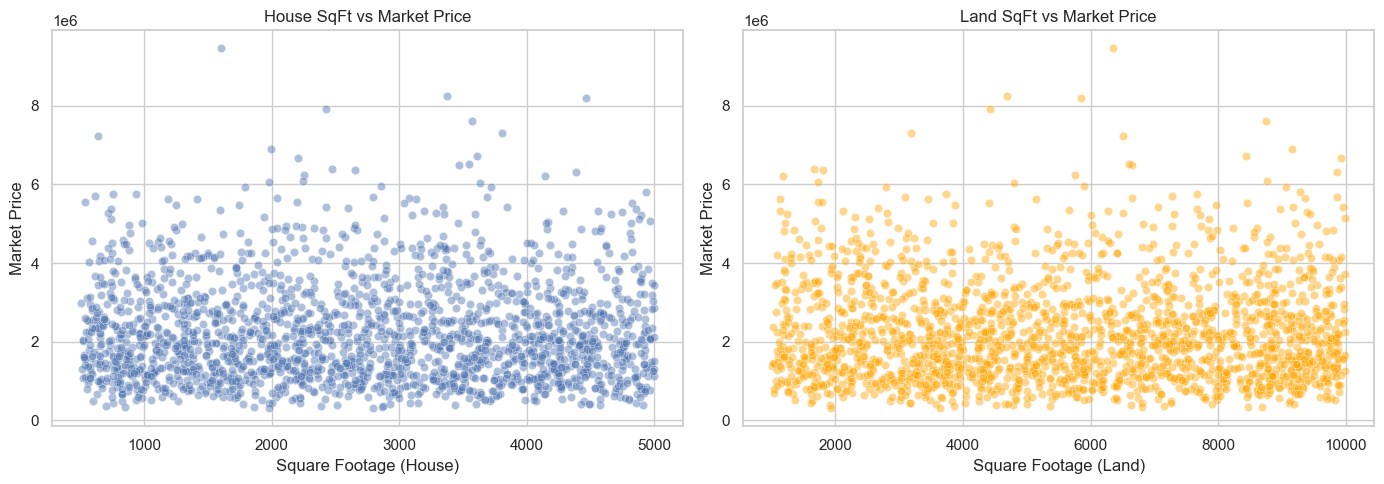

Correlation (House SqFt vs Price): 0.0093
Correlation (Land SqFt vs Price): 0.0002


In [49]:
# Size vs. Price scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df.sample(min(2000, len(df)), random_state=42),
    x="Square Footage (House)", y="Market Price", alpha=0.45, ax=axes[0]
)
axes[0].set_title("House SqFt vs Market Price")

sns.scatterplot(
    data=df.sample(min(2000, len(df)), random_state=42),
    x="Square Footage (Land)", y="Market Price", alpha=0.45, ax=axes[1], color="orange"
)
axes[1].set_title("Land SqFt vs Market Price")

plt.tight_layout()
plt.show()

print("Correlation (House SqFt vs Price):", round(df["Square Footage (House)"].corr(df["Market Price"]), 4))
print("Correlation (Land SqFt vs Price):", round(df["Square Footage (Land)"].corr(df["Market Price"]), 4))

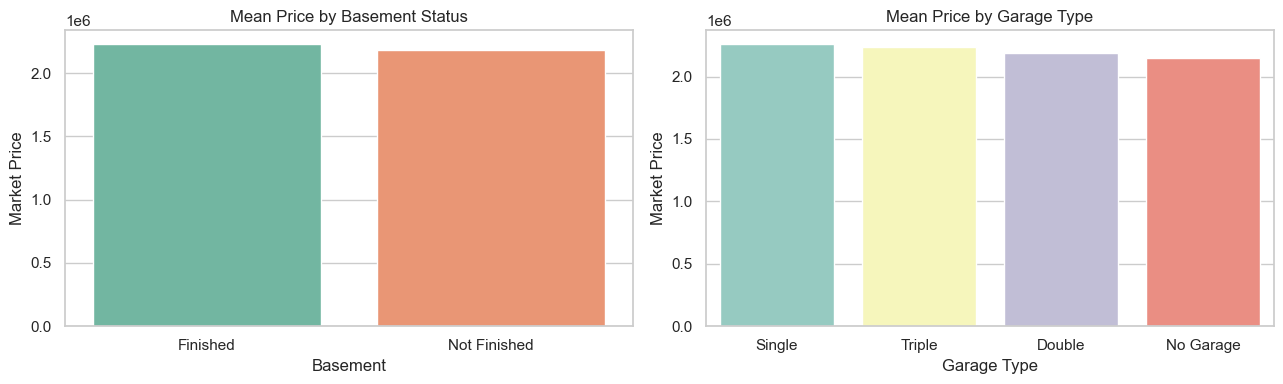

Mean price by basement:
       Basement  Market Price
0      Finished  2.226430e+06
1  Not Finished  2.184218e+06

Mean price by garage type:
  Garage Type  Market Price
2      Single  2.256336e+06
3      Triple  2.237182e+06
0      Double  2.184693e+06
1   No Garage  2.146047e+06


In [50]:
# Amenities: basement and garage impact
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

basement_price = df.groupby("Basement", as_index=False)["Market Price"].mean().sort_values("Market Price", ascending=False)
sns.barplot(data=basement_price, x="Basement", y="Market Price", ax=axes[0], palette="Set2")
axes[0].set_title("Mean Price by Basement Status")

garage_price = df.groupby("Garage Type", as_index=False)["Market Price"].mean().sort_values("Market Price", ascending=False)
sns.barplot(data=garage_price, x="Garage Type", y="Market Price", ax=axes[1], palette="Set3")
axes[1].set_title("Mean Price by Garage Type")

plt.tight_layout()
plt.show()

print("Mean price by basement:")
print(basement_price)
print("\nMean price by garage type:")
print(garage_price)

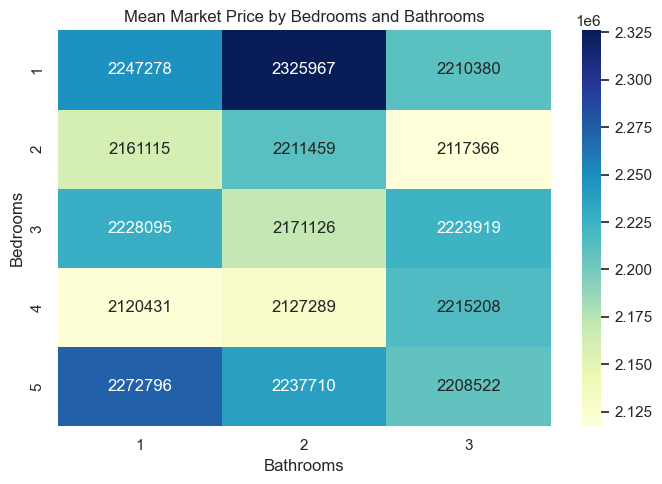

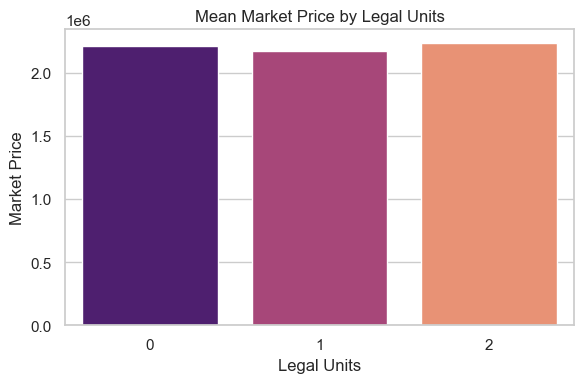

,Legal Units,Market Price
0,0,2.211492e+06
1,1,2.172649e+06
2,2,2.229952e+06


In [51]:
# Configuration effects: Bedrooms, Bathrooms, Legal Units
config_heatmap = df.pivot_table(
    values="Market Price",
    index="Bedrooms",
    columns="Bathrooms",
    aggfunc="mean"
)

plt.figure(figsize=(7, 5))
sns.heatmap(config_heatmap, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Mean Market Price by Bedrooms and Bathrooms")
plt.tight_layout()
plt.show()

legal_units_price = df.groupby("Legal Units", as_index=False)["Market Price"].mean()
plt.figure(figsize=(6, 4))
sns.barplot(data=legal_units_price, x="Legal Units", y="Market Price", palette="magma")
plt.title("Mean Market Price by Legal Units")
plt.tight_layout()
plt.show()

legal_units_price

## 5) Geographic Analysis

In [52]:
# Neighborhood ranking by average price
neighborhood_rank = df.groupby("Neighborhood", as_index=False)["Market Price"].mean().sort_values("Market Price", ascending=False)
neighborhood_rank.head(10)

,Neighborhood,Market Price
26,Lynn Valley,2.506345e+06
17,Edmonds,2.454164e+06
28,Mary Hill,2.419034e+06
34,Seafair,2.416256e+06
39,Uptown,2.384680e+06
3,British Properties,2.382370e+06
30,Mount Pleasant,2.344737e+06
6,Burnaby Heights,2.329097e+06
2,Bridgeport,2.309852e+06
11,Cloverdale,2.309032e+06


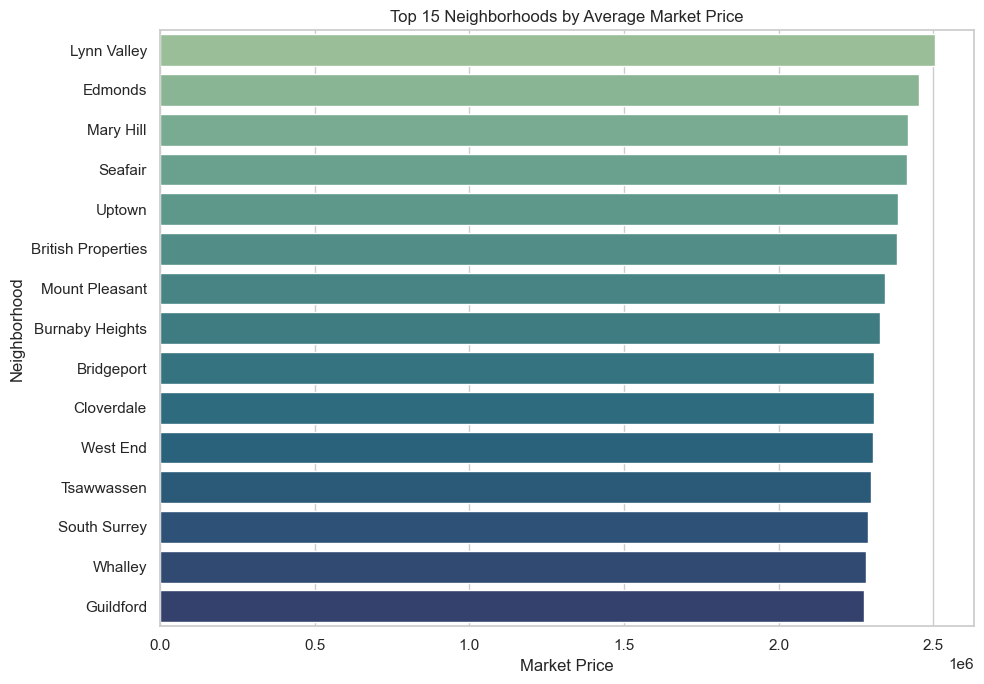

In [53]:
# Plot top 15 neighborhoods by average market price
top_n = 15
plt.figure(figsize=(10, 7))
sns.barplot(
    data=neighborhood_rank.head(top_n),
    y="Neighborhood",
    x="Market Price",
    palette="crest"
)
plt.title(f"Top {top_n} Neighborhoods by Average Market Price")
plt.tight_layout()
plt.show()

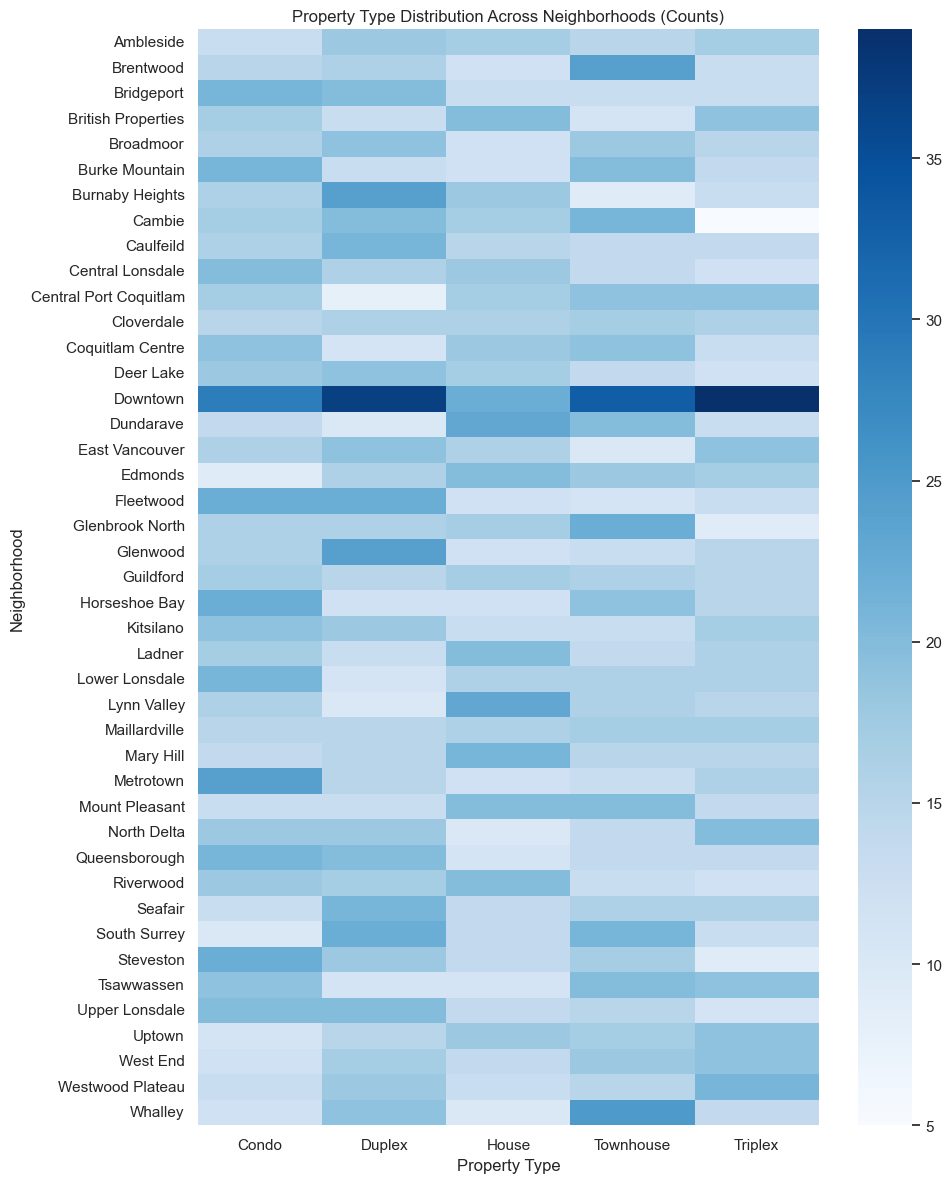

In [54]:
# Property type distribution across neighborhoods
property_mix = pd.crosstab(df["Neighborhood"], df["Property Type"])

plt.figure(figsize=(10, 12))
sns.heatmap(property_mix, cmap="Blues")
plt.title("Property Type Distribution Across Neighborhoods (Counts)")
plt.xlabel("Property Type")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

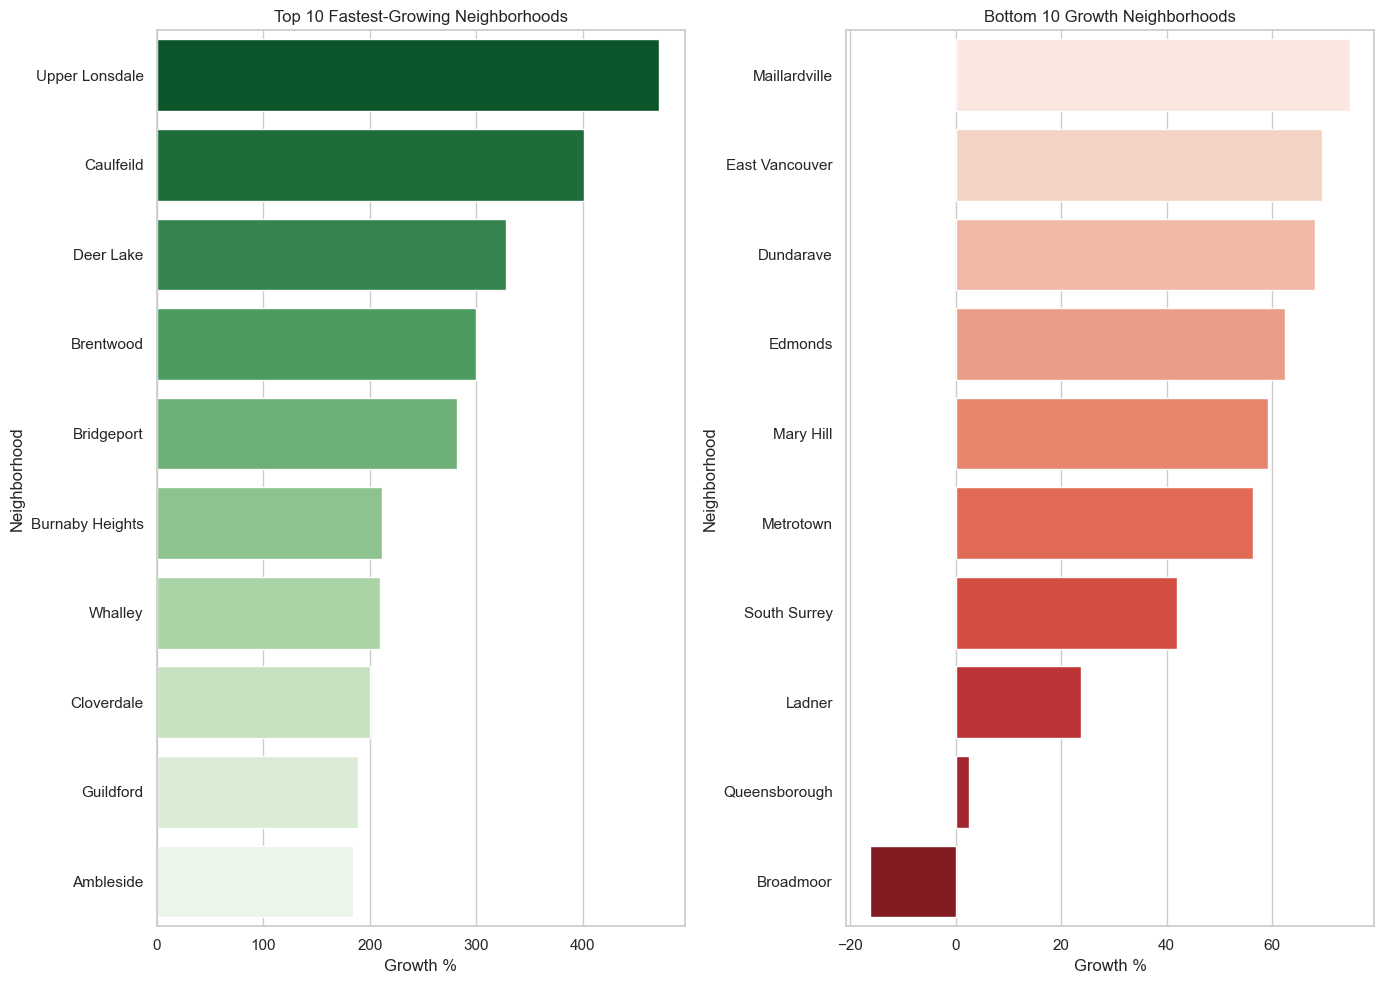

,Neighborhood,Growth %
0,Upper Lonsdale,471.823190
1,Caulfeild,401.283516
2,Deer Lake,327.887735
3,Brentwood,299.772060
4,Bridgeport,281.872641
5,Burnaby Heights,211.465456
6,Whalley,209.540809
7,Cloverdale,199.816395
8,Guildford,188.889229
9,Ambleside,184.520920


In [55]:
# Neighborhood growth rates (first year to last year)
neighborhood_year_trend = df.pivot_table(
    values="Market Price",
    index="Year",
    columns="Neighborhood",
    aggfunc="mean"
)

first_year = neighborhood_year_trend.index.min()
last_year = neighborhood_year_trend.index.max()

neighborhood_growth = ((neighborhood_year_trend.loc[last_year] - neighborhood_year_trend.loc[first_year]) /
                       neighborhood_year_trend.loc[first_year] * 100).sort_values(ascending=False)

growth_df = neighborhood_growth.rename("Growth %").reset_index().rename(columns={"index": "Neighborhood"})

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

sns.barplot(data=growth_df.head(10), y="Neighborhood", x="Growth %", ax=axes[0], palette="Greens_r")
axes[0].set_title("Top 10 Fastest-Growing Neighborhoods")

sns.barplot(data=growth_df.tail(10).sort_values("Growth %", ascending=False), y="Neighborhood", x="Growth %", ax=axes[1], palette="Reds")
axes[1].set_title("Bottom 10 Growth Neighborhoods")

plt.tight_layout()
plt.show()

growth_df

## 6) Final Deliverables

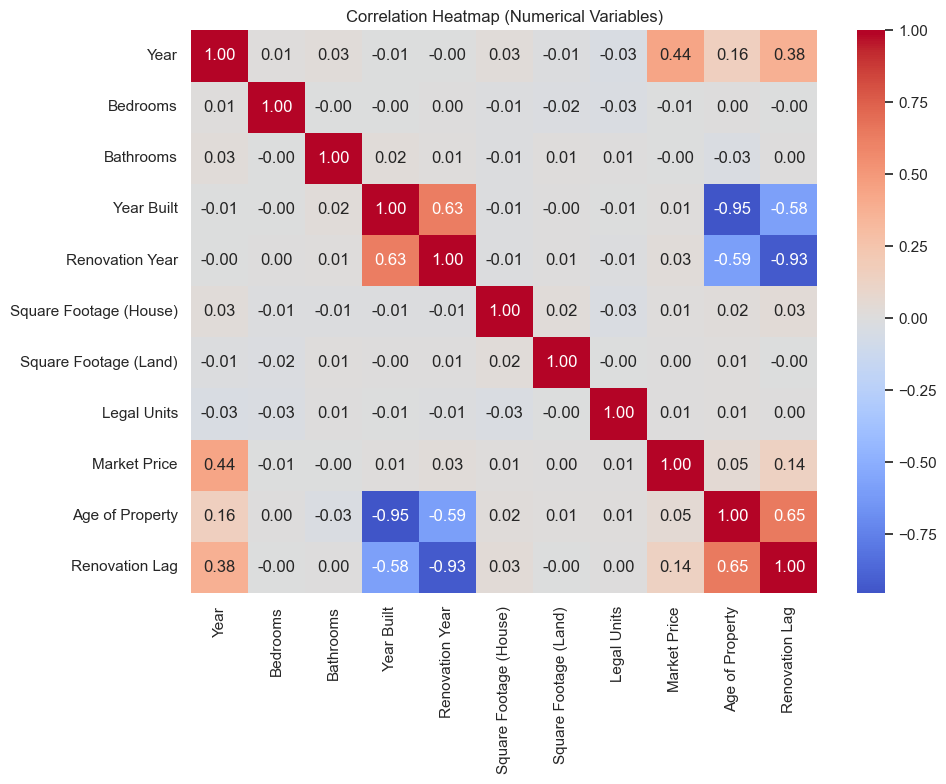

In [56]:
# Correlation heatmap of all numerical variables
numeric_cols = df.select_dtypes(include=["number"]).columns
corr_matrix = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numerical Variables)")
plt.tight_layout()
plt.show()

Top 3 drivers of Market Price:
               importance
Property Type     0.29094
Year              0.25104
Neighborhood      0.10834


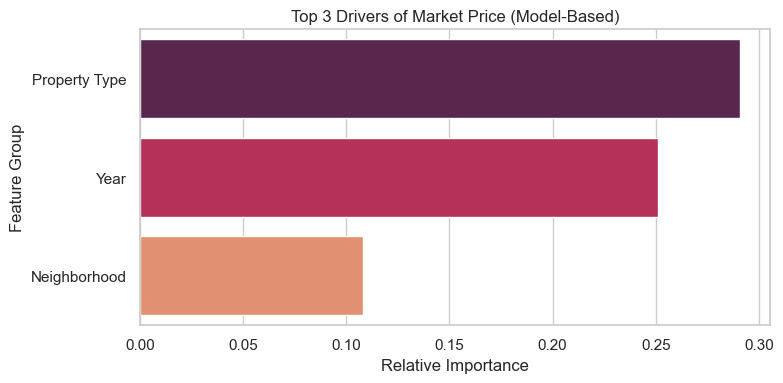

In [57]:
# Top 3 drivers of Market Price using grouped feature importance (Random Forest)
model_df = df.copy()

feature_cols = [
    "Neighborhood", "Year", "Season", "Property Type", "Bedrooms", "Bathrooms",
    "Year Built", "Garage Type", "Square Footage (House)", "Square Footage (Land)",
    "Basement", "Legal Units", "Renovation Status", "Age of Property"
]

model_df["Age of Property"] = model_df["Age of Property"].fillna(0)
X = model_df[feature_cols]
y = model_df["Market Price"]

cat_features = ["Neighborhood", "Season", "Property Type", "Garage Type", "Basement", "Renovation Status"]
num_features = [c for c in feature_cols if c not in cat_features]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("num", "passthrough", num_features),
])

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
pipeline = Pipeline([
    ("prep", preprocess),
    ("model", rf),
])
pipeline.fit(X, y)

cat_names = pipeline.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat_features)
all_feature_names = list(cat_names) + num_features
importances = pipeline.named_steps["model"].feature_importances_

grouped_importance = {}
for fname, imp in zip(all_feature_names, importances):
    base_name = fname.split("_", 1)[0] if fname.split("_", 1)[0] in cat_features else fname
    grouped_importance[base_name] = grouped_importance.get(base_name, 0) + imp

driver_df = (
    pd.Series(grouped_importance, name="importance")
    .sort_values(ascending=False)
    .to_frame()
)

top3 = driver_df.head(3)
print("Top 3 drivers of Market Price:")
print(top3)

plt.figure(figsize=(8, 4))
sns.barplot(x=top3["importance"], y=top3.index, palette="rocket")
plt.title("Top 3 Drivers of Market Price (Model-Based)")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Group")
plt.tight_layout()
plt.show()


### Interpretation Snapshot

- `Year` captures the strong long-term upward trend in pricing over 2004-2023.
- `Property Type` separates market segments (e.g., houses vs condos) with distinct pricing baselines.
- `Neighborhood` captures location-specific pricing levels and differing growth trajectories.

These three features are the strongest combined signals in this synthetic dataset.